In [1]:
from snudd.nsi import earth_matter as em 

In [2]:
from snudd.nsi import oscillation as osc 

In [3]:
from snudd.models import GeneralNSI

In [4]:
import numpy as np

In [5]:
SM_matrix = np.array([[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]])

eta = 0
phi = 0

sm_model = GeneralNSI(SM_matrix, eta, phi)

In [6]:
def my_profile(r):  # r in [0,1]
    # e.g., 2-zone model + tiny crust tweak
    Ye = 0.47 if r < 0.55 else 0.495
    rho = (13.0 - 8.0*r*r) if r < 0.55 else (5.5 - 3.0*(r-0.55))  # g/cm^3
    return Ye * rho

funcmodel = em.CallableEarth(f=my_profile)
EProb = em.EarthProbEvolve(osc_params=osc.osc_params_best, model=sm_model, earthmodel=funcmodel)

In [7]:
EProb.S_matrix(Enu_GeV=10.0, cnadir=0.5)

array([[ 0.68782955+0.5250804j ,  0.37596294-0.01587803j,
         0.3303545 -0.02113625j],
       [ 0.37595142-0.01653217j,  0.0746467 +0.30309717j,
        -0.80544204+0.33497807j],
       [ 0.33029765-0.02172011j, -0.80544951+0.33497884j,
         0.29293045+0.20895865j]])

In [8]:
xr_km = [0., 1221.5, 3480.0, 5701.0, 5771.0, 5971.0, 6151.0,
               6346.6, 6356.0, 6368.0, 6371.0, 6371.0 + 15.0]  # your boundaries
coeffs = [
    (13.0885, 0.0, -8.8381, 0.0),   # layer 1: a,b,c,d in r = R/RE
    (12.5815, -1.2638, -3.6426, -5.528),  # layer 2
    (7.9565,  -6.4761,  5.5283,  -3.0807),  # ...
    (5.3197,  -1.4836,  0.0,  0.0),
    (11.2494,  -8.0298,  0.0,  0.0),
    (7.1089,  -3.8045,  0.0,  0.0),
    (2.6910,   0.6924,  0.0,  0.0),
    (2.9,      0.0,  0.0,  0.0),
    (2.6,    0.0,  0.0,  0.0),
    (1.02,    0.0,  0.0,  0.0),
    (0.000,    0.0,  0.0,  0.0),
]
PREMmodel = em.LayeredPolyEarth(xr_km=xr_km, coeffs=coeffs,
                         Ye_core=0.466, Ye_mantle=0.494)
PREMprob = em.EarthProbEvolve(osc_params=osc.osc_params_best, model=sm_model, earthmodel=PREMmodel, Nst=50, Nav=50 )

In [9]:
PREMprob.S_matrix(Enu_GeV=10.0, cnadir=0.5)

array([[ 0.30660608+0.79554545j,  0.38022408+0.09369932j,
         0.33844917+0.07212761j],
       [ 0.38246773+0.08439559j,  0.08565475+0.30395975j,
        -0.79663542+0.33502173j],
       [ 0.34004164+0.0637781j , -0.79667024+0.33501992j,
         0.29985969+0.20848593j]])

In [10]:
def Probs_diag(Enu_GeV: float, cnadir: float, probevolve) -> np.ndarray:
    S = probevolve.S_matrix(Enu_GeV, cnadir)
    amps = S[:, 0]                 # first column → νe→{e,μ,τ}
    return np.abs(amps)**2         # array([Pee, Peμ, Peτ])


In [11]:
from joblib import Parallel, delayed

def Probs_diag_parallel(Enu_array, cnadir, propagator, n_jobs=-1):
    results = Parallel(n_jobs=n_jobs)(
        delayed(Probs_diag)(E, cnadir, propagator) for E in Enu_array
    )
    probs = np.vstack(results).T
    return probs

In [12]:
?


IPython -- An enhanced Interactive Python

IPython offers a fully compatible replacement for the standard Python
interpreter, with convenient shell features, special commands, command
history mechanism and output results caching.

At your system command line, type 'ipython -h' to see the command line
options available. This document only describes interactive features.

GETTING HELP
------------

Within IPython you have various way to access help:

  ?         -> Introduction and overview of IPython's features (this screen).
  object?   -> Details about 'object'.
  object??  -> More detailed, verbose information about 'object'.
  %quickref -> Quick reference of all IPython specific syntax and magics.
  help      -> Access Python's own help system.

If you are in terminal IPython you can quit this screen by pressing `q`.


MAIN FEATURES
-------------

* Access to the standard Python help with object docstrings and the Python
  manuals. Simply type 'help' (no quotes) to invoke it.

* Ma

In [13]:

xspace = np.linspace(1.0/2e1, 1.0/1e-3, 10000)

Enuspace=1/xspace

Pee, Pemu, Petau = Probs_diag_parallel(Enuspace, 1.0, PREMprob, n_jobs=4)

In [14]:
1/Enuspace[0]

0.05

In [15]:
import matplotlib.pyplot as plt


First we're just trying to understand where the atmospheric mass splitting needs to have enough sampling in energy. $L_{\rm vac} = 4 \pi E_\nu /\Delta m^2$, $L_{\rm vac} = L_{\rm earth}$ when $E_\nu= L_{\rm earth} \Delta m^2 / 4\pi\approx 5.6\times10^3\, {\rm GeV} \left(\frac{L}{R_{\rm Earth }}\right) \left(\frac{\Delta m^2}{1\, {\rm eV}^2}\right)\,$ 

Text(0.5, 1.0, '$\\cos(\\eta)=0.025$')

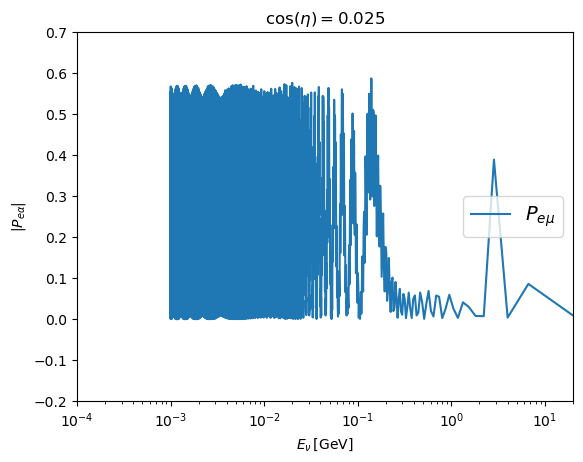

In [16]:

# plt.semilogx(Enuspace, Pee, label=r'$P_{ee}$')
plt.semilogx(Enuspace, Pemu, label=r'$P_{e\mu}$')
# plt.semilogx(Enuspace, Petau, label=r'$P_{e\tau}$')

plt.ylim(ymin=-0.2, ymax=0.7)
plt.xlim(xmin=1e-4, xmax=2.0e1)

plt.xlabel(r'$E_{\nu}\,\left[{\rm GeV}\right]$')
plt.ylabel(r'$\vert P_{e \alpha}\vert$')
plt.legend(fontsize=14, loc='right')
plt.title(r'$\cos(\eta)=0.025$')

Text(0.5, 1.0, '$\\cos(\\eta)=0.025$')

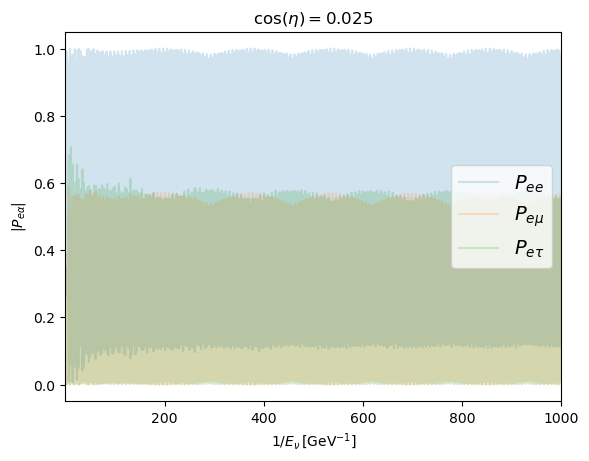

In [17]:

plt.plot(1/Enuspace, Pee, label=r'$P_{ee}$', alpha=0.2)
plt.plot(1/Enuspace, Pemu, label=r'$P_{e\mu}$', alpha=0.2)
plt.plot(1/Enuspace, Petau, label=r'$P_{e\tau}$', alpha=0.2)

#plt.ylim(ymin=-0.2, ymax=0.7)
plt.xlim(xmin=1/2e1, xmax=1/1e-3)

plt.xlabel(r'$1/E_{\nu}\,\left[{\rm GeV}^{-1}\right]$')
plt.ylabel(r'$\vert P_{e \alpha}\vert$')
plt.legend(fontsize=14, loc='right')
plt.title(r'$\cos(\eta)=0.025$')

In [18]:
from scipy.ndimage import uniform_filter1d

def averaged_probability(x_grid, P_grid, dm2=2.5e-3 * 1e-18, L_km= 3.23e22):
    """
    x_grid : uniform grid in 1/E (GeV^-1)
    P_grid : oscillation probability on that grid
    dm2    : Delta m^2 in eV^2
    L_km   : baseline in km
    """
    dx = x_grid[1] - x_grid[0]                     # grid spacing in 1/E
    cycle_width = 10*4.0 * np.pi / (dm2 * L_km)       # one full sin^2 cycle
    window = int(np.round(cycle_width / dx))        # points per cycle
    if window < 1:
        window = 1
    # Running mean over one cycle width
    P_avg = uniform_filter1d(P_grid, size=window, mode='nearest')
    return P_avg

In [19]:
def adaptive_average(x_grid, P_grid, dm2_31=2.5e-3 * 1e-18, dm2_21=7e-5*1e-18, L_km= 3.23e22, threshold=3.0):
    """
    Adaptive boxcar averaging on a uniform 1/E grid.

    Parameters
    ----------
    x_grid    : 1d array, uniform grid in 1/E (GeV^-1)
    P_grid    : 1d array, oscillation probabilities
    dm2_31    : float, atmospheric splitting (eV^2)
    dm2_21    : float, solar splitting (eV^2)
    L_km      : float, baseline (km)
    threshold : float, minimum N_cycles to trigger averaging

    Returns
    -------
    P_avg : 1d array, adaptively averaged probabilities
    """
    dx = x_grid[1] - x_grid[0]
    E_grid = 1.0 / x_grid

    # Cycle widths in 1/E space (constant on this grid)
    Leff = L_km / 1.267
    dx_atm = 10* 4.0 * np.pi / (dm2_31 * Leff)
    dx_sol = 10* 4.0 * np.pi / (dm2_21 * Leff)

    win_atm = max(int(np.round(dx_atm / dx)), 1)
    win_sol = max(int(np.round(dx_sol / dx)), 1)

    # Number of cycles at each energy
    N_atm = dm2_31 * L_km / (4.0 * np.pi * E_grid * 1.267)
    N_sol = dm2_21 * L_km / (4.0 * np.pi * E_grid * 1.267)

    # Pre-compute both smoothed versions
    P_avg_atm = uniform_filter1d(P_grid, size=win_atm, mode='nearest')
    P_avg_sol = uniform_filter1d(P_grid, size=win_sol, mode='nearest')

    # Adaptive selection at each point
    P_avg = np.copy(P_grid)

    # Where solar oscillations are fast → use solar window
    # (this automatically averages out atm too, since dx_sol >> dx_atm)
    mask_sol = N_sol > threshold
    P_avg[mask_sol] = P_avg_sol[mask_sol]

    # Where only atmospheric oscillations are fast → use atm window
    mask_atm = (N_atm > threshold) & (~mask_sol)
    P_avg[mask_atm] = P_avg_atm[mask_atm]

    # Where neither is fast → keep raw (no averaging)
    # (already handled by the initial np.copy)

    return P_avg

In [20]:
# --- Boxcar averaging ---
Pee_av = averaged_probability(xspace, Pee)

Pee_adav = adaptive_average(xspace, Pee)

Text(0.5, 1.0, '$\\cos(\\eta)=0.025$')

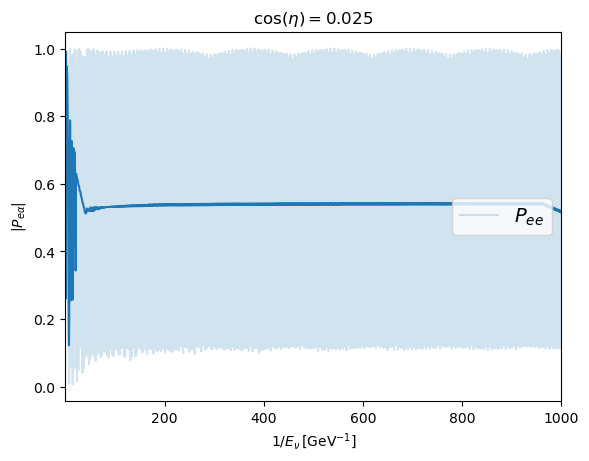

In [21]:

plt.plot(1/Enuspace, Pee, label=r'$P_{ee}$', alpha=0.2)
#plt.plot(xspace, Pee_av, color=r'tab:blue', ls=':')
plt.plot(xspace, Pee_adav, color=r'tab:blue')


#plt.ylim(ymin=-0.2, ymax=0.7)
plt.xlim(xmin=1/2e1, xmax=1/1e-3)

plt.xlabel(r'$1/E_{\nu}\,\left[{\rm GeV}^{-1}\right]$')
plt.ylabel(r'$\vert P_{e \alpha}\vert$')
plt.legend(fontsize=14, loc='right')
plt.title(r'$\cos(\eta)=0.025$')

In [22]:
# --- Boxcar averaging ---
dx = xspace[1] - xspace[0]
cycle_width = 4.0 * np.pi / (2e-5 *1e-18* 3.2e22)  # in GeV^-1
window = max(int(np.round(cycle_width / dx)), 1)
Pee_boxavg = uniform_filter1d(Pee, size=window, mode='nearest')

Text(0.5, 1.0, '$\\cos(\\eta)=0.025$')

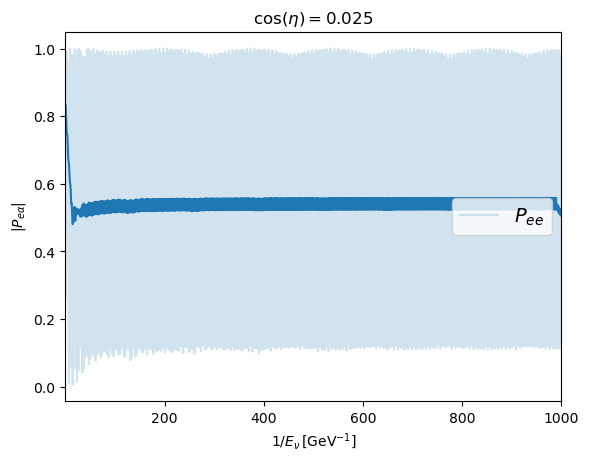

In [23]:

plt.plot(1/Enuspace, Pee, label=r'$P_{ee}$', alpha=0.2)
#plt.plot(xspace, Pee_av, color=r'tab:blue', ls=':')
plt.plot(xspace, Pee_boxavg, color=r'tab:blue')


#plt.ylim(ymin=-0.2, ymax=0.7)
plt.xlim(xmin=1/2e1, xmax=1/1e-3)

plt.xlabel(r'$1/E_{\nu}\,\left[{\rm GeV}^{-1}\right]$')
plt.ylabel(r'$\vert P_{e \alpha}\vert$')
plt.legend(fontsize=14, loc='right')
plt.title(r'$\cos(\eta)=0.025$')

In [24]:
def detector_smeared(x_grid, P_grid, frac_resolution=0.10):
    """
    Gaussian smearing with sigma_x = frac_resolution * x
    (mimics fractional energy resolution sigma_E/E = frac_resolution)
    """
    dx = x_grid[1] - x_grid[0]
    P_smeared = np.zeros_like(P_grid)

    for i, x0 in enumerate(x_grid):
        sigma_x = frac_resolution * x0         # variable width
        # Truncate kernel at ±3 sigma
        half_w = int(np.ceil(3.0 * sigma_x / dx))
        j_lo = max(i - half_w, 0)
        j_hi = min(i + half_w + 1, len(x_grid))

        weights = np.exp(-0.5 * ((x_grid[j_lo:j_hi] - x0) / sigma_x)**2)
        weights /= weights.sum()
        P_smeared[i] = np.dot(weights, P_grid[j_lo:j_hi])

    return P_smeared


In [25]:
import tqdm as tqdm

In [26]:

Pee_smearavg = detector_smeared(xspace,Pee, frac_resolution=0.05)

Pemu_smearavg = detector_smeared(xspace,Pemu, frac_resolution=0.05)

Petau_smearavg = detector_smeared(xspace,Petau, frac_resolution=0.05)

Text(0.5, 1.0, '$\\cos(\\eta)=0.025$')

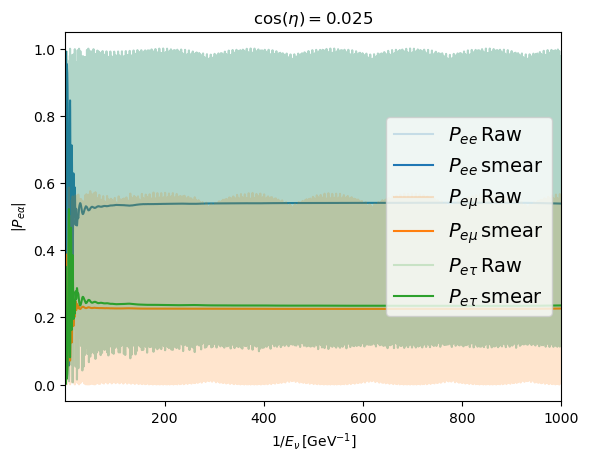

In [27]:

plt.plot(1/Enuspace, Pee, label=r'$P_{ee}\,{\rm Raw}$', alpha=0.2)
#plt.plot(xspace, Pee_av, color=r'tab:blue', ls=':')
plt.plot(xspace, Pee_smearavg, color=r'tab:blue', label=r'$P_{ee}\,{\rm smear}$')


plt.plot(1/Enuspace, Pemu, label=r'$P_{e\mu}\,{\rm Raw}$', alpha=0.2)
#plt.plot(xspace, Pee_av, color=r'tab:blue', ls=':')
plt.plot(xspace, Pemu_smearavg, color=r'tab:orange', label=r'$P_{e\mu}\,{\rm smear}$')



plt.plot(1/Enuspace, Pee, label=r'$P_{e\tau}\,{\rm Raw}$', alpha=0.2)
#plt.plot(xspace, Pee_av, color=r'tab:blue', ls=':')
plt.plot(xspace, Petau_smearavg, label=r'$P_{e\tau}\,{\rm smear}$',color=r'tab:green')


#plt.ylim(ymin=-0.2, ymax=0.7)
plt.xlim(xmin=1/2e1, xmax=1/1e-3)

plt.xlabel(r'$1/E_{\nu}\,\left[{\rm GeV}^{-1}\right]$')
plt.ylabel(r'$\vert P_{e \alpha}\vert$')
plt.legend(fontsize=14, loc='right')
plt.title(r'$\cos(\eta)=0.025$')

In [28]:
osc.UPMNS(osc.osc_params_best)

array([[ 0.81685303+0.j,  0.55721936+0.j,  0.14919019+0.j],
       [-0.46115332+0.j,  0.47543448+0.j,  0.74919935+0.j],
       [ 0.34653822+0.j, -0.68078531+0.j,  0.64532365+0.j]])

In [29]:
def three_flavor_prob_averaged(alpha, beta, osc_params=osc.osc_params_best):
    """
    Calculates the 3-flavor vacuum oscillation probability in the 
    fast-oscillation (averaged) regime.

    Note: L and E are not required as oscillations average out.
    Note: CP violation (delta_cp) does not affect the final magnitude 
    in this averaged limit, but is kept for matrix construction consistency.
    """

    # Construct PMNS matrix
    U = osc.UPMNS(osc.osc_params_best)



    # Sum over mass eigenstates k
    # P_avg = Sum_k |U_alpha_k|^2 * |U_beta_k|^2
    prob = 0.0
    for k in range(3):
        prob += np.abs(U[alpha, k])**2 * np.abs(U[beta, k])**2

    return np.real(prob)

In [30]:
import ACstyle 

Text(0.5, 1.0, '$\\cos(\\eta)=0.025$')

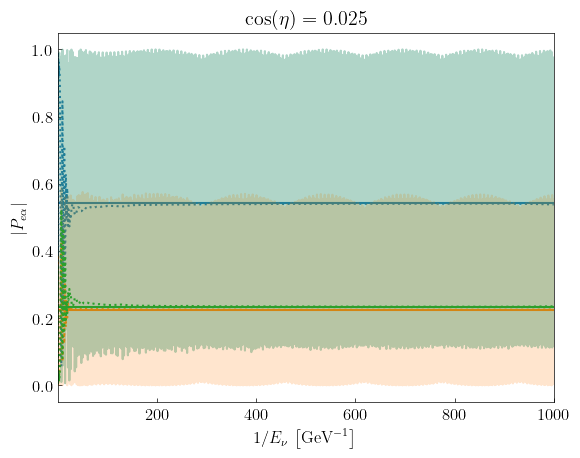

In [31]:


plt.plot(1/Enuspace, Pee, label=r'$P_{ee}\,{\rm Raw}$', alpha=0.2)
#plt.plot(xspace, Pee_av, color=r'tab:blue', ls=':')
plt.plot(xspace, Pee_smearavg, color=r'tab:blue', label=r'$P_{ee}\,{\rm smear}$', ls=':')

plt.axhline(three_flavor_prob_averaged(0, 0), color='tab:blue', ls='-')



plt.plot(1/Enuspace, Pemu, label=r'$P_{e\mu}\,{\rm Raw}$', alpha=0.2)
#plt.plot(xspace, Pee_av, color=r'tab:blue', ls=':')
plt.plot(xspace, Pemu_smearavg, color=r'tab:orange', label=r'$P_{e\mu}\,{\rm smear}$', ls=':')
plt.axhline(three_flavor_prob_averaged(0, 1), color='tab:orange')



plt.plot(1/Enuspace, Pee, label=r'$P_{e\tau}\,{\rm Raw}$', alpha=0.2)
#plt.plot(xspace, Pee_av, color=r'tab:blue', ls=':')
plt.plot(xspace, Petau_smearavg, label=r'$P_{e\tau}\,{\rm smear}$',color=r'tab:green', ls=':')
plt.axhline(three_flavor_prob_averaged(0, 2), color='tab:green')



#plt.ylim(ymin=-0.2, ymax=0.7)
plt.xlim(xmin=1/2e1, xmax=1/1e-3)

plt.xlabel(r'$1/E_{\nu}\,\left[{\rm GeV}^{-1}\right]$')
plt.ylabel(r'$\vert P_{e \alpha}\vert$')
#plt.legend(fontsize=14, loc='right')
plt.title(r'$\cos(\eta)=0.025$')

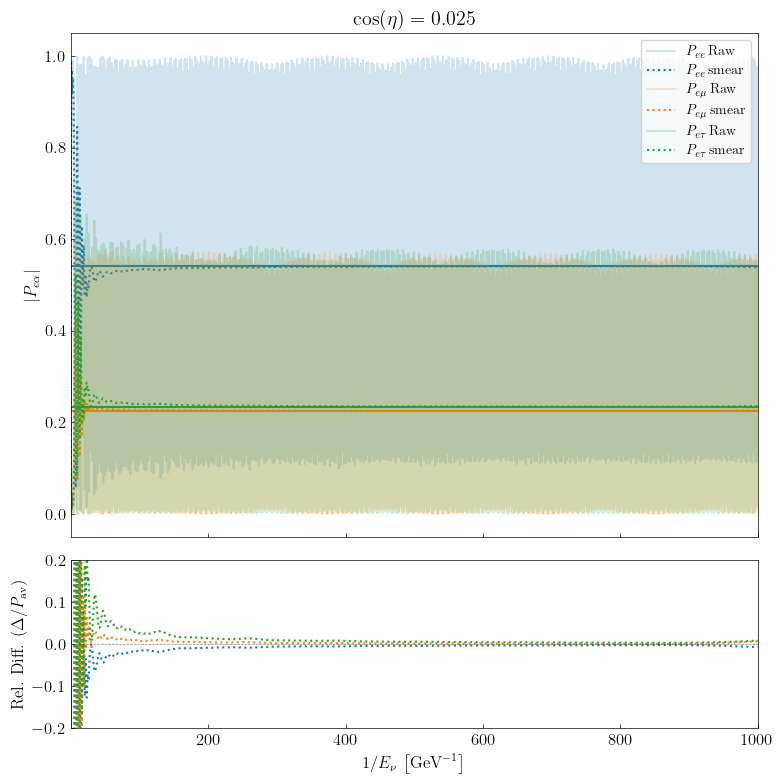

In [32]:
# --- Create the figure with two subplots sharing the x-axis ---
# height_ratios=[3, 1] makes the top panel 3 times larger than the bottom
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# --- UPPER PANEL (Your Plotting Logic) ---
# Plot P_ee
ax1.plot(1/Enuspace, Pee, label=r'$P_{ee}\,{\rm Raw}$', alpha=0.2)
ax1.plot(xspace, Pee_smearavg, color='tab:blue', label=r'$P_{ee}\,{\rm smear}$', ls=':')
ax1.axhline(three_flavor_prob_averaged(0, 0), color='tab:blue', ls='-')

# Plot P_emu
ax1.plot(1/Enuspace, Pemu, label=r'$P_{e\mu}\,{\rm Raw}$', alpha=0.2)
ax1.plot(xspace, Pemu_smearavg, color='tab:orange', label=r'$P_{e\mu}\,{\rm smear}$', ls=':')
ax1.axhline(three_flavor_prob_averaged(0, 1), color='tab:orange')

# Plot P_etau
# Note: Assuming 'Petau_raw' or similar variable exists for the 'Raw' tau line, 
# as 'Pee' seemed to be a typo in the snippet.
ax1.plot(1/Enuspace, Petau, 
         label=r'$P_{e\tau}\,{\rm Raw}$', alpha=0.2)
ax1.plot(xspace, Petau_smearavg, label=r'$P_{e\tau}\,{\rm smear}$', color='tab:green', ls=':')
ax1.axhline(three_flavor_prob_averaged(0, 2), color='tab:green')

ax1.set_ylabel(r'$\vert P_{e \alpha}\vert$')
ax1.set_title(r'$\cos(\eta)=0.025$')
ax1.legend(loc='best', fontsize=10)

# --- LOWER PANEL (Relative Difference) ---
# Calculate the scalar average probabilities for normalization
P_avg_ee = three_flavor_prob_averaged(0, 0)
P_avg_em = three_flavor_prob_averaged(0, 1)
P_avg_et = three_flavor_prob_averaged(0, 2)

# Calculate relative difference: (Smeared - Averaged) / Averaged
rel_diff_ee = (Pee_smearavg - P_avg_ee) / P_avg_ee
rel_diff_em = (Pemu_smearavg - P_avg_em) / P_avg_em
rel_diff_et = (Petau_smearavg - P_avg_et) / P_avg_et

# Plot the relative differences matching the colors
ax2.plot(xspace, rel_diff_ee, color='tab:blue', ls=':')
ax2.plot(xspace, rel_diff_em, color='tab:orange', ls=':')
ax2.plot(xspace, rel_diff_et, color='tab:green', ls=':')

# Add a reference line at 0
ax2.axhline(0, color='black', lw=0.5, ls='--', alpha=0.5)

# Labels and Limits
ax2.set_xlabel(r'$1/E_{\nu}\,\left[{\rm GeV}^{-1}\right]$')
ax2.set_ylabel(r'Rel. Diff. $(\Delta/P_{\rm av})$')
ax2.set_xlim(xmin=1/2e1, xmax=1/1e-3)

# Optional: Set consistent y-limits for the lower panel or auto-scale
ax2.set_ylim(-0.2, 0.2) 

plt.tight_layout()
plt.show()

In [172]:
1/300

0.0033333333333333335

In [171]:
np.min(abs(rel_diff_ee[:])), rel_diff_em[-1], rel_diff_et[-1]

(0.0014712942259141005, 0.006960614666431638, 0.008863112392138151)

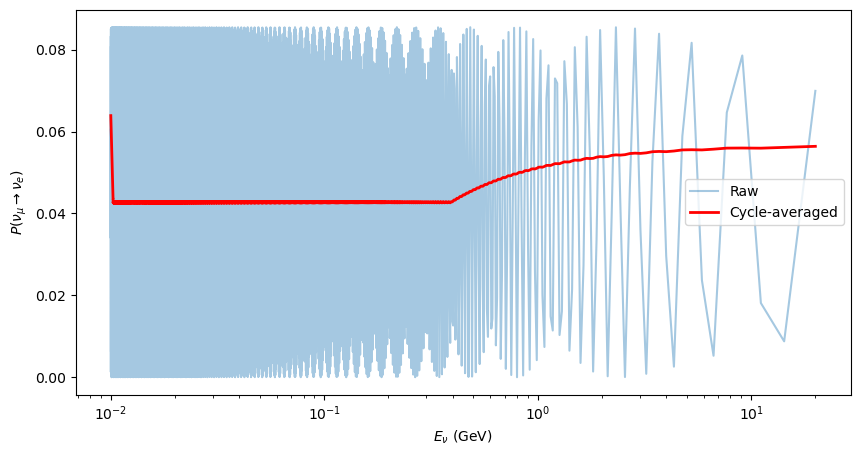

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

# --- Setup ---
dm2   = 2.5e-3    # eV^2
L     = 12700.0   # km
E_min, E_max = 0.01, 20.0  # GeV

# Uniform grid in 1/E
x_min, x_max = 1.0/E_max, 1.0/E_min
N_pts = 5000
x_grid = np.linspace(x_min, x_max, N_pts)
E_grid = 1.0 / x_grid

# --- Your oscillation probabilities (placeholder: vacuum 2-flavor) ---
theta = np.radians(8.5)
phase = dm2 * L / (4.0 * E_grid)              # in natural units (km·eV^2/GeV)
# Convert: 1.267 factor for km, GeV, eV^2
phase_proper = 1.267 * dm2 * L / E_grid
P = np.sin(2*theta)**2 * np.sin(phase_proper)**2

# --- Boxcar averaging ---
dx = x_grid[1] - x_grid[0]
cycle_width = 10*4.0 * np.pi / (dm2 * L / 1.267)  # in GeV^-1
window = max(int(np.round(cycle_width / dx)), 1)
P_avg = uniform_filter1d(P, size=window, mode='nearest')

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(E_grid, P, alpha=0.4, label='Raw')
ax.plot(E_grid, P_avg, 'r', lw=2, label='Cycle-averaged')
ax.set_xscale('log')
ax.set_xlabel(r'$E_\nu$ (GeV)')
ax.set_ylabel(r'$P(\nu_\mu \to \nu_e)$')
ax.legend()
plt.show()


In [21]:
def evolve_through_earth(rho_solar_stack, enus_GeV, cnadir, probevolve):
    """
    rho_solar_stack: (N,3,3) complex array  [your solar density matrices at Earth surface]
    enus_GeV       : (N,) energies
    cnadir           : scalar cos(nadir)
    propagator     : an object with S_matrix(E, cnadir) -> (3,3) complex

    Returns:
      rho_earth_stack : (N,3,3) complex
    """
    # 1) build S(E) for all energies
    S_list = [probevolve.S_matrix(E, cnadir) for E in enus_GeV]
    S = np.stack(S_list, axis=0)                    # (N,3,3)
    Sdag = np.swapaxes(S.conj(), -1, -2)            # (N,3,3)

    # 2) batch multiply: S ρ S†   (use matmul with batch dims)
    tmp = np.matmul(S, rho_solar_stack)             # (N,3,3)
    rho_earth = np.matmul(tmp, Sdag)                # (N,3,3)


    return rho_earth 

In [22]:
import snudd.nsi.nsi_probabilities as probs

In [ ]:
density_sm = probs.SolarDensityMatrixCalculator(sm_model).density(Enuspace, '8B')

In [24]:
rho_earth = evolve_through_earth(density_sm, Enuspace, cnadir=np.cos(np.pi/2- np.pi*25.0/180) , probevolve=PREMprob)


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

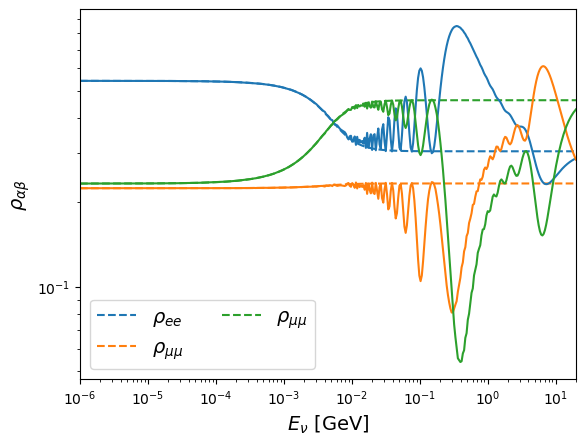

In [25]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_earth[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_earth[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_earth[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

#plt.loglog(Enuspace, Pee*, label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

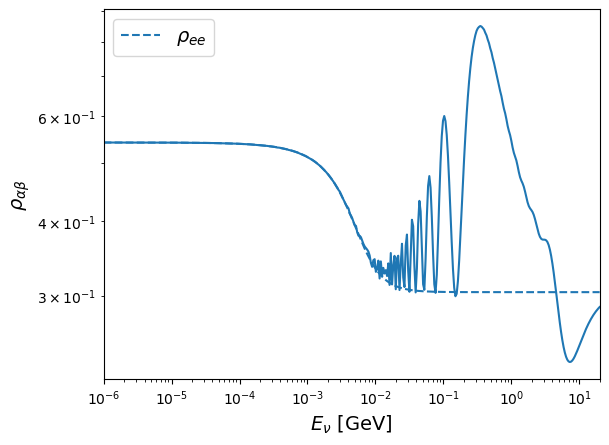

In [26]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
            
plt.loglog(Enuspace,abs(rho_earth[:, 0,0]),  color="tab:blue" )


# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace, Pee*abs(density_sm[:, 0,0]), label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [27]:
from snudd.nsi.oscillation import OscillationParameters

In [28]:
delta_m12 = 7.42e-5 *( 1e-9) ** 2 # GeV^2
delta_m31 = 2.517e-3 * (1e-9) ** 2  # GeV^2
theta_12 = np.arcsin(np.sqrt(0.304))
theta_13 = np.arcsin(np.sqrt(0.02219)) # NORMAL ORDERING
theta_23 = np.arcsin(np.sqrt(0.573))
delta_cp = 4.71238898038469  # CP angle

params1 = OscillationParameters(delta_m12, delta_m31,
                                        theta_12,
                                        theta_13,
                                        theta_23,
                                        delta_cp)

In [ ]:
rho_sun2 = probs.SolarDensityMatrixCalculator(sm_model, osc_params=params1).density(Enuspace, '8B')

In [30]:
PREMprob2 = em.EarthProbEvolve(osc_params=params1, model=sm_model, earthmodel=PREMmodel)

In [31]:
rho_earth2 = evolve_through_earth(rho_sun2, Enuspace, cnadir=0.025, probevolve=PREMprob2)


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

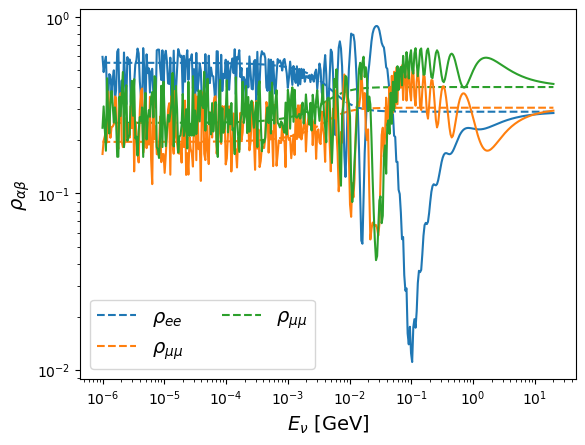

In [32]:
plt.loglog(Enuspace,abs(rho_sun2[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(rho_sun2[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(rho_sun2[:, 2,2]),  label=r'$\rho_{\mu\mu}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_earth2[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_earth2[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_earth2[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [33]:
Pee2, Pemu2, Petau2 = Probs_diag_parallel(Enuspace, 0.025, PREMprob2, n_jobs=4)

Text(0.5, 1.0, '$\\cos(\\eta)=0.025$')

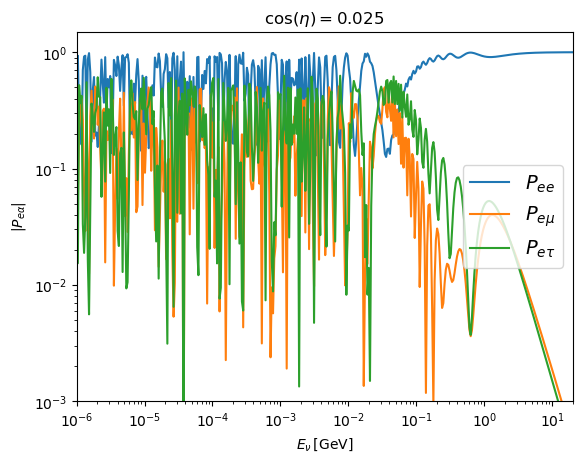

In [34]:

plt.loglog(Enuspace, Pee2, label=r'$P_{ee}$')
plt.loglog(Enuspace, Pemu2, label=r'$P_{e\mu}$')
plt.loglog(Enuspace, Petau2, label=r'$P_{e\tau}$')

plt.ylim(ymin=1e-3, ymax=1.5)
plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.xlabel(r'$E_{\nu}\,\left[{\rm GeV}\right]$')
plt.ylabel(r'$\vert P_{e \alpha}\vert$')
plt.legend(fontsize=14, loc='right')
plt.title(r'$\cos(\eta)=0.025$')

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

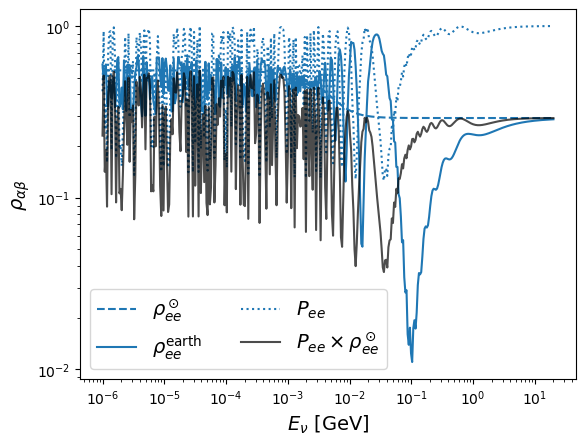

In [35]:
plt.loglog(Enuspace,abs(rho_sun2[:, 0,0]),  label=r'$\rho_{ee}^\odot$', 
            color="tab:blue", ls='--' )

plt.loglog(Enuspace,abs(rho_earth2[:, 0,0]),  label=r'$\rho_{ee}^{\rm earth}$',  color="tab:blue" )


plt.loglog(Enuspace, Pee2, label=r'$P_{ee}$', ls=':', color="tab:blue" )

plt.loglog(Enuspace, abs(Pee2*rho_sun2[:, 0,0]), label=r'$P_{ee}\times\rho_{ee}^\odot$', ls='-', color="k", alpha=0.7 )


# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

Fewer slabs in the numerical calculation 

In [ ]:
PREMprop3 = em.EarthProbEvolve(osc_params=params1, model=sm_model, earthmodel=PREMmodel,
                               Nst=50, Nav=50)

In [40]:
rho_earth3 = evolve_through_earth(rho_sun2, Enuspace, cnadir=0.025, probevolve=PREMprop3)



(1e-06, 20.0)

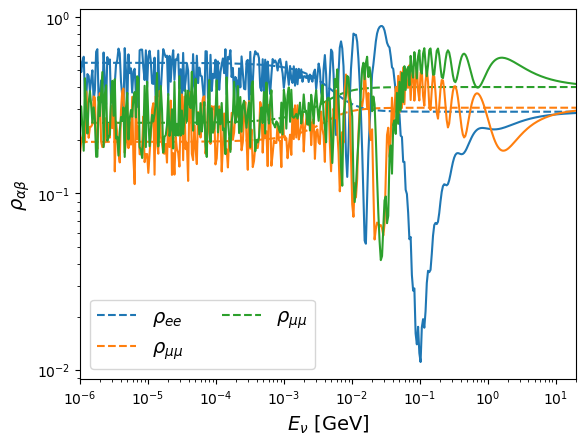

In [41]:
plt.loglog(Enuspace,abs(rho_sun2[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(rho_sun2[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(rho_sun2[:, 2,2]),  label=r'$\rho_{\mu\mu}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_earth3[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_earth3[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_earth3[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)
plt.xlim(xmin=1e-6, xmax=2.0e1)


In [42]:
delta_m12 = 7.42e-5 *( 1e-9) ** 2 # GeV^2
delta_m31 = 2.517e-3 * (1e-9) ** 2  # GeV^2
theta_12 = np.arcsin(np.sqrt(0.304))
theta_13 = np.arcsin(np.sqrt(0.02219)) # NORMAL ORDERING
theta_23 = np.arcsin(np.sqrt(0.573))
delta_cp0 = 0.0

params_cp0 = OscillationParameters(delta_m12, delta_m31,
                                        theta_12,
                                        theta_13,
                                        theta_23,
                                        delta_cp0)

In [ ]:
rho_suncp0 = probs.SolarDensityMatrixCalculator(sm_model, osc_params=params_cp0).density(Enuspace, '8B')

In [45]:
PREMpropcp0 = em.EarthProbEvolve(osc_params=params_cp0, model=sm_model, earthmodel=PREMmodel,
                               Nst=50, Nav=50)


In [46]:
rho_earth_cp0 = evolve_through_earth(rho_suncp0, Enuspace, cnadir=0.025, probevolve=PREMpropcp0)


(1e-06, 20.0)

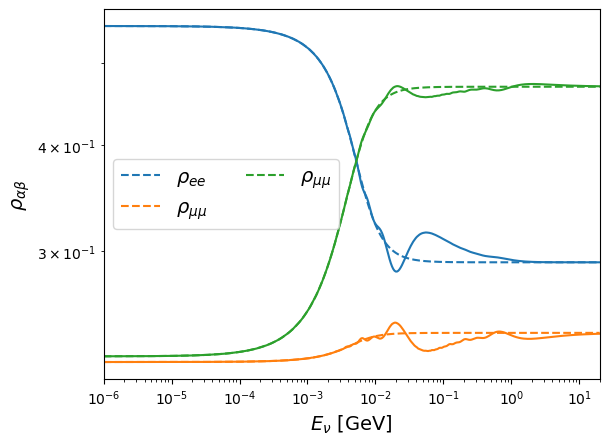

In [47]:
plt.loglog(Enuspace,abs(rho_suncp0[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(rho_suncp0[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(rho_suncp0[:, 2,2]),  label=r'$\rho_{\mu\mu}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_earth_cp0[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_earth_cp0[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_earth_cp0[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)
plt.xlim(xmin=1e-6, xmax=2.0e1)